<a href="https://colab.research.google.com/github/swati-tiwary/employee_attrition_prediction/blob/develop/Ai_Project_Employee_Attrition_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset loaded successfully.

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHou

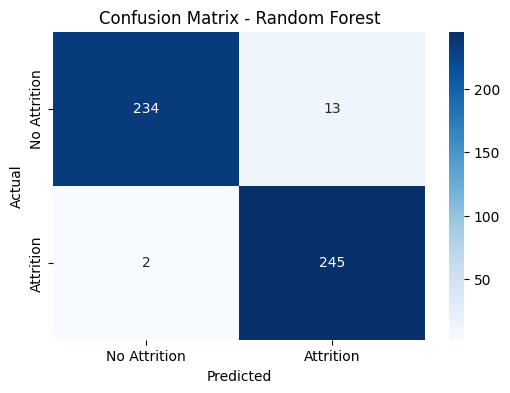

Sample Employee Prediction
Predicted Attrition (0 = No, 1 = Yes): 1


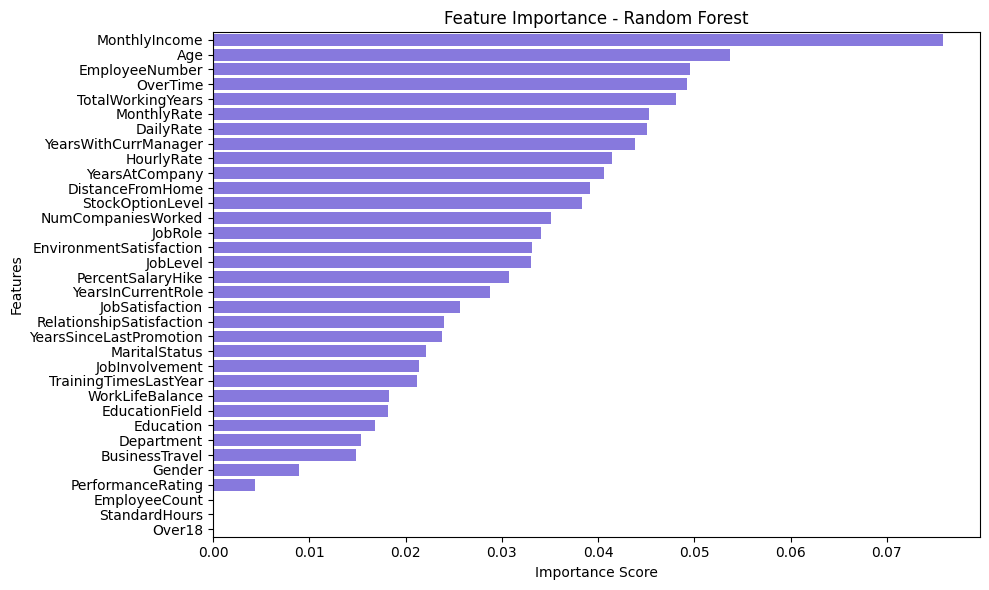


Top 5 Features Contributing to Attrition
1. MonthlyIncome - Importance: 0.0759
2. Age - Importance: 0.0537
3. EmployeeNumber - Importance: 0.0496
4. OverTime - Importance: 0.0492
5. TotalWorkingYears - Importance: 0.0481


In [ ]:
# STEP 1: Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample


# STEP 2: Load dataset: Kaggle HR Employee Attrition dataset
data = pd.read_csv("employee_attrition.csv")
print("Dataset loaded successfully.\n")
print(data.head())

# STEP 3: Data overview
print("\nData Info:") #column names, data types, and non-null counts.
print(data.info())
print("\nData Description:")#statistics (mean, min, max, quartiles)
print(data.describe())
print("\nMissing values in dataset:\n", data.isnull().sum())

# STEP 4: Encode categorical variables
label_enc = LabelEncoder()
for col in data.select_dtypes(include=['object']).columns:
    data[col] = label_enc.fit_transform(data[col])

# STEP 5: Balance the dataset using upsampling for Attrition = 1
df_majority = data[data.Attrition == 0]
df_minority = data[data.Attrition == 1]

df_minority_upsampled = resample(
    df_minority,
    replace=True,             # sample with replacement
    n_samples=len(df_majority), # match majority class
    random_state=42
)

data_balanced = pd.concat([df_majority, df_minority_upsampled])
print(f"\nBalanced dataset shape: {data_balanced.shape}")
print(data_balanced['Attrition'].value_counts())

# STEP 6: Define features and target
X = data_balanced.drop("Attrition", axis=1)
y = data_balanced["Attrition"]

# STEP 7: Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# STEP 8: Scale numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# STEP 9: Train Random Forest model
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# STEP 10: Evaluate model
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# Clear Results Section
print("\n" + "="*40)
print("          MODEL PERFORMANCE RESULTS")
print("="*40)
print(f"Accuracy : {acc_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}\n")

print("Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

# STEP 11: Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Attrition','Attrition'],
            yticklabels=['No Attrition','Attrition'])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# STEP 12: Example prediction
sample = X_test[0].reshape(1, -1)
prediction = rf.predict(sample)
print("="*40)
print("Sample Employee Prediction")
print("="*40)
print(f"Predicted Attrition (0 = No, 1 = Yes): {prediction[0]}")

# STEP 13: Feature Importance Visualization
importances = rf.feature_importances_
feature_names = X.columns

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot all features (no warning)
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feat_imp,
    color='mediumslateblue'  # use color instead of palette
)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

# STEP 14: Display Top 5 Features (clean numbering)
top_features = feat_imp.head(5)
print("\n" + "="*40)
print("Top 5 Features Contributing to Attrition")
print("="*40)
for i, (_, row) in enumerate(top_features.iterrows(), start=1):
    print(f"{i}. {row['Feature']} - Importance: {row['Importance']:.4f}")

